# Classical Baseline — TF-IDF + Linear Classifiers
### SEA 820 · GenDetect · Part 2 (Member A)

**Goal:** establish the honest **baseline score** the DistilBERT model must beat, on the
*exact same* test set produced by `data_processing/data_split.py`.

**Design (from EDA + TODO):**
- Input = the pre-computed **`text_classical`** column (heavy-cleaned, lemmatized) — no re-running the pipeline.
- TF-IDF is **fit on train only**, then transforms val/test (no leakage).
- Model selection happens on the **validation** set; the **test** set is touched **once**, at the end.
- Headline metric = **macro-F1** + per-class recall, because the data is imbalanced (63% human / 37% AI).
- We compare **default vs `class_weight='balanced'`**, and add **length features** as an engineering bonus.

> **Runtime:** Google Colab. Upload `metrics.py` and `tfidf_features.py` into your Drive
> `NLP_project/` folder (next to `preprocessing.py`) so the import below works.

## 0. Setup — mount Drive & import shared modules

In [1]:
# Mount Google Drive (holds the split parquet files + the shared .py modules)
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time
import numpy as np
import pandas as pd

DRIVE_DIR = '/content/drive/MyDrive/NLP_project'
PROC_DIR  = os.path.join(DRIVE_DIR, 'processed')     # train/val/test.parquet live here
RESULTS   = os.path.join(DRIVE_DIR, 'classical_results')
os.makedirs(RESULTS, exist_ok=True)

# Import the shared project modules (uploaded next to preprocessing.py on Drive).
sys.path.append(DRIVE_DIR)
import tfidf_features as tf
import metrics as M

print('Drive dir :', DRIVE_DIR)
print('Processed :', os.listdir(PROC_DIR) if os.path.isdir(PROC_DIR) else 'NOT FOUND')
print('Results -> ', RESULTS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive dir : /content/drive/MyDrive/NLP_project
Processed : ['train.parquet', 'val.parquet', 'test.parquet']
Results ->  /content/drive/MyDrive/NLP_project/classical_results


## 1. Load the canonical splits
We load the same train/val/test the Transformer will use. We model on **`text_classical`**;
we keep the raw **`text`** around only for length features and error analysis.

In [2]:
def load_split(name):
    path = os.path.join(PROC_DIR, f'{name}.parquet')
    df = pd.read_parquet(path)
    return df

train = load_split('train')
val   = load_split('val')
test  = load_split('test')

for name, d in [('train', train), ('val', val), ('test', test)]:
    bal = d['label'].value_counts(normalize=True).sort_index()
    print(f'{name:5s}: {len(d):>7,} rows | human {bal.get(0,0):.1%} / AI {bal.get(1,0):.1%}')

print('\ncolumns:', train.columns.tolist())

# Guard: text_classical must exist.
assert 'text_classical' in train.columns, 'text_classical column missing — re-run data_split.py'

train: 341,061 rows | human 62.8% / AI 37.2%
val  :  73,085 rows | human 62.8% / AI 37.2%
test :  73,085 rows | human 62.8% / AI 37.2%

columns: ['text', 'label', 'text_clean', 'text_classical']


## 2. Build TF-IDF features (fit on TRAIN only)
`tfidf_features.fit_transform` fits the vectorizer on train and only *transforms* val/test,
so no test vocabulary/IDF leaks into training.

In [3]:
t0 = time.time()

vec, X_train, X_val, X_test = tf.fit_transform(
    train['text_classical'], val['text_classical'], test['text_classical'],
    max_features=50000, ngram_range=(1, 2), min_df=5, max_df=0.9,
)

y_train, y_val, y_test = train['label'].values, val['label'].values, test['label'].values

print(f'fit+transform in {time.time()-t0:.0f}s')
print(f'X_train: {X_train.shape}  (docs x features)')
print(f'X_val  : {X_val.shape}')
print(f'X_test : {X_test.shape}')


density = X_train.nnz / (X_train.shape[0] * X_train.shape[1])
print(f'vocabulary size : {len(vec.get_feature_names_out()):,}')
print(f'matrix density  : {density*100:.3f}%  (sparse -> memory-cheap)')

fit+transform in 206s
X_train: (341061, 50000)  (docs x features)
X_val  : (73085, 50000)
X_test : (73085, 50000)
vocabulary size : 50,000
matrix density  : 0.387%  (sparse -> memory-cheap)


## 3. Baseline — Logistic Regression
 We evaluate on **validation** — the test set stays sealed.
`liblinear` is a good fit for high-dimensional sparse text.

In [4]:
from sklearn.linear_model import LogisticRegression

results_val = {}   # collect val metrics for every model we try

lr = LogisticRegression(max_iter=1000, C=1.0, solver='liblinear', random_state=42)
lr.fit(X_train, y_train)
results_val['LogReg (default)'] = M.print_metrics('LogReg (default) — VAL', y_val, lr.predict(X_val))

=== LogReg (default) — VAL ===
  accuracy : 0.9973
  macro-F1 : 0.9971   <- headline metric (imbalance-aware)
  AI    P/R/F1: 0.9987 / 0.9940 / 0.9964
  human P/R/F1: 0.9965 / 0.9992 / 0.9978


## 4. Class-imbalance experiment — default vs `class_weight='balanced'`
The TODO/EDA decision: only reweight the **training** set (val/test stay at the natural 63/37).
`balanced` makes the minority **AI** class count more, which usually **raises AI recall** — we
check whether that helps or hurts macro-F1.

In [5]:
lr_bal = LogisticRegression(max_iter=1000, C=1.0, solver='liblinear',
                            class_weight='balanced', random_state=42)

lr_bal.fit(X_train, y_train)
results_val['LogReg (balanced)'] = M.print_metrics(
    'LogReg (class_weight=balanced) — VAL', y_val, lr_bal.predict(X_val))

print('\nTakeaway: compare AI recall and macro-F1 above. `balanced` trades a little')
print('human precision for higher AI recall — keep it only if macro-F1 improves.')

=== LogReg (class_weight=balanced) — VAL ===
  accuracy : 0.9977
  macro-F1 : 0.9976   <- headline metric (imbalance-aware)
  AI    P/R/F1: 0.9978 / 0.9961 / 0.9970
  human P/R/F1: 0.9977 / 0.9987 / 0.9982

Takeaway: compare AI recall and macro-F1 above. `balanced` trades a little
human precision for higher AI recall — keep it only if macro-F1 improves.


## 5. Stretch — Naive Bayes & Linear SVM
For top marks the rubric wants **2+ classic models compared**. Both are fast on sparse TF-IDF.
- **MultinomialNB** — classic text baseline, very fast.
- **LinearSVC** — often the strongest linear text classifier.

In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

nb = MultinomialNB()
nb.fit(X_train, y_train)
results_val['MultinomialNB'] = M.print_metrics('MultinomialNB — VAL', y_val, nb.predict(X_val))

svm = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
results_val['LinearSVC (balanced)'] = M.print_metrics('LinearSVC (balanced) — VAL', y_val, svm.predict(X_val))

=== MultinomialNB — VAL ===
  accuracy : 0.9765
  macro-F1 : 0.9748   <- headline metric (imbalance-aware)
  AI    P/R/F1: 0.9780 / 0.9585 / 0.9682
  human P/R/F1: 0.9757 / 0.9872 / 0.9814
=== LinearSVC (balanced) — VAL ===
  accuracy : 0.9995
  macro-F1 : 0.9995   <- headline metric (imbalance-aware)
  AI    P/R/F1: 0.9993 / 0.9994 / 0.9994
  human P/R/F1: 0.9997 / 0.9996 / 0.9996


### Validation leaderboard so far

In [7]:
val_table = M.results_table(results_val)
display(val_table.round(4))
print('\nHeadline = macro_f1. Best model on val:', val_table.index[0])

,accuracy,macro_f1,f1_AI,recall_AI,precision_AI,f1_human
LinearSVC (balanced),0.9995,0.9995,0.9994,0.9994,0.9993,0.9996
LogReg (balanced),0.9977,0.9976,0.9970,0.9961,0.9978,0.9982
LogReg (default),0.9973,0.9971,0.9964,0.9940,0.9987,0.9978
MultinomialNB,0.9765,0.9748,0.9682,0.9585,0.9780,0.9814



Headline = macro_f1. Best model on val: LinearSVC (balanced)


## 6. Hyperparameter tuning (selected on VALIDATION)
We already have a dedicated val set, so we tune against it directly instead of running
5-fold `GridSearchCV` on 341k rows (much cheaper, and honest). Two quick stages:

**6a. TF-IDF shape** — does adding bigrams / more features help?

In [8]:
def eval_vectorizer(ngram_range, max_features, model_factory):
    vc, Xtr, Xvl = tf.fit_transform(
        train['text_classical'], val['text_classical'],
        max_features=max_features, ngram_range=ngram_range, min_df=5, max_df=0.9)
    mdl = model_factory()
    mdl.fit(Xtr, y_train)
    m = M.compute_metrics(y_val, mdl.predict(Xvl))
    return m['macro_f1'], vc

lr_factory = lambda: LogisticRegression(max_iter=1000, C=1.0, solver='liblinear',
                                        class_weight='balanced', random_state=42)

grid = [((1, 1), 20000), ((1, 1), 50000), ((1, 2), 50000), ((1, 2), 100000)]
print('ngram   max_feat   val_macroF1')
best = (-1, None, None)

for ng, mf in grid:
    score, _ = eval_vectorizer(ng, mf, lr_factory)
    print(f'{str(ng):7s} {mf:>8,}   {score:.4f}')
    if score > best[0]:
        best = (score, ng, mf)
print(f'\nBest TF-IDF config on val: ngram={best[1]}, max_features={best[2]:,} (macro-F1={best[0]:.4f})')
BEST_NGRAM, BEST_MAXF = best[1], best[2]

ngram   max_feat   val_macroF1
(1, 1)    20,000   0.9946
(1, 1)    50,000   0.9947
(1, 2)    50,000   0.9976
(1, 2)   100,000   0.9976

Best TF-IDF config on val: ngram=(1, 2), max_features=50,000 (macro-F1=0.9976)


## 6b. Tune regularization `C` — for BOTH LogReg and LinearSVC
We carry the two linear models forward (LinearSVC won on the val leaderboard; LogReg
stays for a fair 2-model comparison). Both are tuned on **validation** with the winning
TF-IDF config; the test set stays sealed.

In [9]:
from sklearn.svm import LinearSVC

# Rebuild features once with the winning TF-IDF config from 6a.
vec, X_train, X_val, X_test = tf.fit_transform(
    train['text_classical'], val['text_classical'], test['text_classical'],
    max_features=BEST_MAXF, ngram_range=BEST_NGRAM, min_df=5, max_df=0.9)

Cs = [0.1, 0.5, 1.0, 3.0, 10.0]

def tune_C(make):
    best = (-1, None)
    for C in Cs:
        f1 = M.compute_metrics(y_val, make(C).fit(X_train, y_train).predict(X_val))['macro_f1']
        print(f'  C={C:<5} val_macroF1={f1:.4f}')
        if f1 > best[0]:
            best = (f1, C)
    return best[1]

print('LogReg:')
BEST_C_LR = tune_C(lambda C: LogisticRegression(
    max_iter=1000, C=C, solver='liblinear', class_weight='balanced', random_state=42))


print('LinearSVC:')
BEST_C_SVM = tune_C(lambda C: LinearSVC(C=C, class_weight='balanced', random_state=42))
print(f'Best C -> LogReg={BEST_C_LR}, LinearSVC={BEST_C_SVM}')

LogReg:
  C=0.1   val_macroF1=0.9911
  C=0.5   val_macroF1=0.9963
  C=1.0   val_macroF1=0.9976
  C=3.0   val_macroF1=0.9987
  C=10.0  val_macroF1=0.9994
LinearSVC:
  C=0.1   val_macroF1=0.9985
  C=0.5   val_macroF1=0.9993
  C=1.0   val_macroF1=0.9995
  C=3.0   val_macroF1=0.9997
  C=10.0  val_macroF1=0.9998
Best C -> LogReg=10.0, LinearSVC=10.0


## 7. Length-feature check — on both models
EDA showed humans write longer/more variable than AI. We hstack log(char) + log(word)
counts and see if val macro-F1 moves for either model. At this ceiling it usually doesn't.

In [10]:
X_train_len = tf.stack_length(X_train, train['text'])
X_val_len   = tf.stack_length(X_val,   val['text'])

def mk(nm, C):
    if nm == 'LogReg':
        return LogisticRegression(max_iter=1000, C=C, solver='liblinear',
                                  class_weight='balanced', random_state=42)
    return LinearSVC(C=C, class_weight='balanced', random_state=42)

svm_len_helps = False
for nm, C in [('LogReg', BEST_C_LR), ('LinearSVC', BEST_C_SVM)]:
    w  = M.compute_metrics(y_val, mk(nm, C).fit(X_train,     y_train).predict(X_val))['macro_f1']
    wl = M.compute_metrics(y_val, mk(nm, C).fit(X_train_len, y_train).predict(X_val_len))['macro_f1']
    print(f'{nm:10s} words-only={w:.4f}  +length={wl:.4f}  -> {"keep" if wl > w else "drop"}')
    if nm == 'LinearSVC':
        svm_len_helps = wl > w

USE_LENGTH = bool(svm_len_helps)
print('USE_LENGTH =', USE_LENGTH)

LogReg     words-only=0.9994  +length=0.9994  -> drop
LinearSVC  words-only=0.9998  +length=0.9998  -> keep
USE_LENGTH = True


## 8. FINAL — train BOTH models on train+val, evaluate ONCE on test
After selecting on val, we refit on **train + val** (all non-test data) and score both models
on the sealed test set. The higher macro-F1 is **the baseline the Transformer must beat**.

In [11]:
trainval_text = pd.concat([train['text_classical'], val['text_classical']])
trainval_y    = np.concatenate([y_train, y_val])

vec_final = tf.build_vectorizer(max_features=BEST_MAXF, ngram_range=BEST_NGRAM,
                                min_df=5, max_df=0.9)
X_tv         = vec_final.fit_transform(trainval_text)
X_test_final = vec_final.transform(test['text_classical'])
if USE_LENGTH:
    X_tv         = tf.stack_length(X_tv,         pd.concat([train['text'], val['text']]))
    X_test_final = tf.stack_length(X_test_final, test['text'])

final_models = {
    'LogReg':    LogisticRegression(max_iter=1000, C=BEST_C_LR, solver='liblinear',
                                    class_weight='balanced', random_state=42),
    'LinearSVC': LinearSVC(C=BEST_C_SVM, class_weight='balanced', random_state=42),
}

results_test, preds = {}, {}
for name, mdl in final_models.items():
    mdl.fit(X_tv, trainval_y)
    preds[name] = mdl.predict(X_test_final)
    results_test[name] = M.print_metrics(f'{name} — TEST', y_test, preds[name])
    print()

best_name  = max(results_test, key=lambda k: results_test[k]['macro_f1'])
best_model = final_models[best_name]
y_pred     = preds[best_name]
baseline   = results_test[best_name]
print('>>> Best on TEST:', best_name)
print(M.report(y_test, y_pred))

=== LogReg — TEST ===
  accuracy : 0.9995
  macro-F1 : 0.9995   <- headline metric (imbalance-aware)
  AI    P/R/F1: 0.9993 / 0.9993 / 0.9993
  human P/R/F1: 0.9996 / 0.9996 / 0.9996

=== LinearSVC — TEST ===
  accuracy : 0.9997
  macro-F1 : 0.9997   <- headline metric (imbalance-aware)
  AI    P/R/F1: 0.9996 / 0.9997 / 0.9996
  human P/R/F1: 0.9998 / 0.9997 / 0.9998

>>> Best on TEST: LinearSVC
              precision    recall  f1-score   support

       human     0.9998    0.9997    0.9998     45870
          AI     0.9996    0.9997    0.9996     27215

    accuracy                         0.9997     73085
   macro avg     0.9997    0.9997    0.9997     73085
weighted avg     0.9997    0.9997    0.9997     73085



### Confusion matrix — best model on test

[saved] /content/drive/MyDrive/NLP_project/classical_results/confusion_test.png


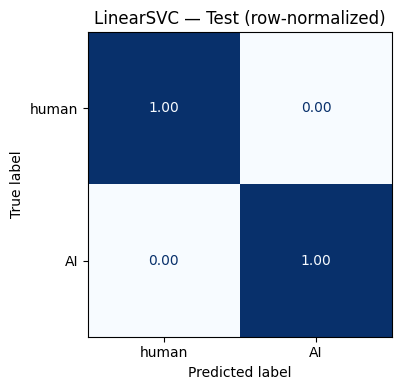

In [12]:
import matplotlib.pyplot as plt
fig = M.plot_confusion(y_test, y_pred, normalize='true',
                       title=f'{best_name} — Test (row-normalized)',
                       savepath=os.path.join(RESULTS, 'confusion_test.png'))
plt.show()
# Bottom-left cell = humans wrongly flagged as AI (the ethically sensitive errors).

## 8b. Diagnostics — should we trust a ~99.9% score?
A near-perfect supervised result must be *interrogated*, not celebrated. These plots run the
standard checks: (1) how close all the models are, (2) **ROC / Precision-Recall** curves with
AUC, (3) **class separability**, and (4) **cross-validation** consistency across folds.
Conclusion: the score is *genuine on this dataset*, but it rides on how easily separable the
data is — the artifact story in **10b** explains why it won't generalize.

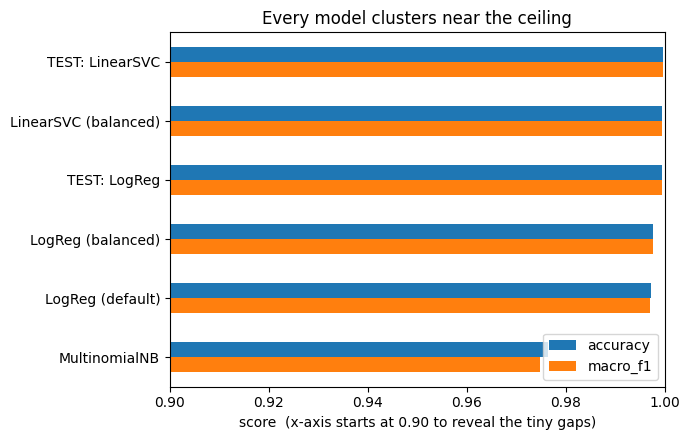

Interpretation: when every model lands within ~1-2 points at the top, the TASK is easy,
not the model clever. First clue to distrust a near-perfect score.


In [13]:
# (1) How close are all the models? Bar chart with a zoomed x-axis.
import matplotlib.pyplot as plt

comp = M.results_table({**results_val,
                        **{f'TEST: {k}': v for k, v in results_test.items()}})
ax = comp[['accuracy', 'macro_f1']].astype(float).plot(kind='barh', figsize=(7, 4.5))
ax.set_xlim(0.90, 1.0)
ax.invert_yaxis()
ax.set_xlabel('score  (x-axis starts at 0.90 to reveal the tiny gaps)')
ax.set_title('Every model clusters near the ceiling')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'model_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Interpretation: when every model lands within ~1-2 points at the top, the TASK is easy,')
print('not the model clever. First clue to distrust a near-perfect score.')

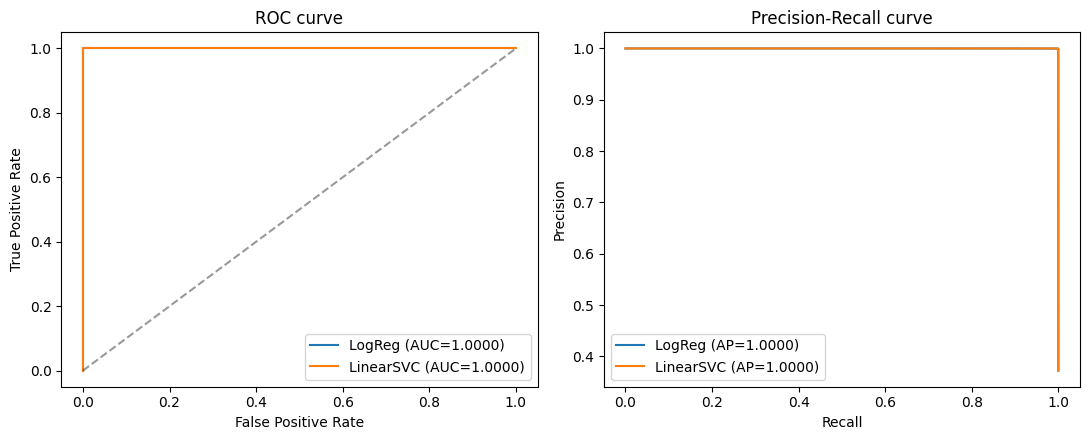

AUC ~1.0 with a steep ROC = near-perfect separability ON THIS DATA (genuine here).
The catch (10b): the separation rides on dataset artifacts, so it will not transfer.


In [14]:
# (2) ROC and Precision-Recall curves for both models (AI = positive class).
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for name, mdl in final_models.items():
    score = mdl.decision_function(X_test_final)          # both linear models expose this
    fpr, tpr, _ = roc_curve(y_test, score)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.4f})')
    prec, rec, _ = precision_recall_curve(y_test, score)
    ax2.plot(rec, prec, label=f'{name} (AP={average_precision_score(y_test, score):.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=.4)
ax1.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC curve')
ax1.legend(loc='lower right')
ax2.set(xlabel='Recall', ylabel='Precision', title='Precision-Recall curve')
ax2.legend(loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'roc_pr_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print('AUC ~1.0 with a steep ROC = near-perfect separability ON THIS DATA (genuine here).')
print('The catch (10b): the separation rides on dataset artifacts, so it will not transfer.')

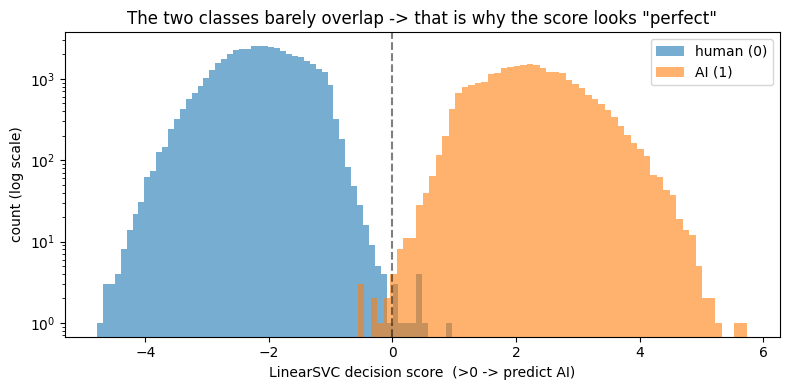

In [15]:
# (3) Class separability: distribution of the best model's decision scores by true class.
scores = best_model.decision_function(X_test_final)
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test == 0], bins=60, alpha=.6, label='human (0)')
plt.hist(scores[y_test == 1], bins=60, alpha=.6, label='AI (1)')
plt.axvline(0, color='k', ls='--', alpha=.5)
plt.yscale('log')  # log so the tiny overlap region is visible
plt.xlabel(f'{best_name} decision score  (>0 -> predict AI)')
plt.ylabel('count (log scale)')
plt.title('The two classes barely overlap -> that is why the score looks "perfect"')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'separability.png'), dpi=120, bbox_inches='tight')
plt.show()

5-fold macro-F1 : [0.9932 0.9927 0.9923 0.9923 0.9936]
mean=0.9928  std=0.0005


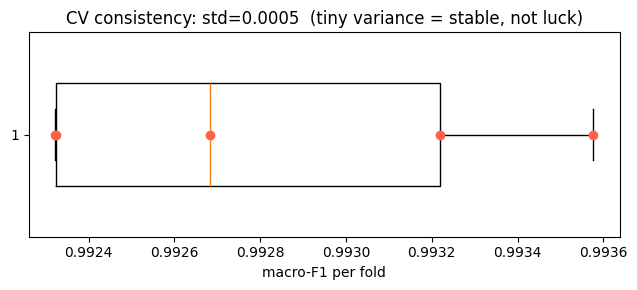

In [16]:
# (4) Cross-validation consistency: is the score stable, or a lucky split?
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split

# Lightweight: 5-fold CV on a 30k stratified subsample (full-data CV would be slow).
sub, _ = train_test_split(train, train_size=30000, stratify=train['label'], random_state=42)
pipe = Pipeline([
    ('tfidf', tf.build_vectorizer(max_features=BEST_MAXF, ngram_range=BEST_NGRAM,
                                  min_df=5, max_df=0.9)),
    ('clf', LogisticRegression(max_iter=1000, C=BEST_C_LR, solver='liblinear',
                               class_weight='balanced', random_state=42)),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, sub['text_classical'], sub['label'],
                            cv=cv, scoring='f1_macro', n_jobs=-1)
print('5-fold macro-F1 :', np.round(cv_scores, 4))
print('mean=%.4f  std=%.4f' % (cv_scores.mean(), cv_scores.std()))

plt.figure(figsize=(6.5, 3))
plt.boxplot(cv_scores, vert=False, widths=.5)
plt.scatter(cv_scores, np.ones_like(cv_scores), color='tomato', zorder=3)
plt.xlabel('macro-F1 per fold')
plt.title(f'CV consistency: std={cv_scores.std():.4f}  (tiny variance = stable, not luck)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'cv_consistency.png'), dpi=120, bbox_inches='tight')
plt.show()

## 9. What each model learned — top words per class
Both are linear, so `.coef_` ranks the words pushing toward **AI** vs **human**. Compare the
two models and cross-check against the EDA.

In [17]:
names = np.array(vec_final.get_feature_names_out())
for name, mdl in final_models.items():
    coefs = mdl.coef_[0][:len(names)]        # trim any appended length-feature coefs
    top_ai = coefs.argsort()[-20:][::-1]
    top_hu = coefs.argsort()[:20]
    print(f'--- {name} ---')
    print('  AI   :', ', '.join(names[top_ai]))
    print('  HUMAN:', ', '.join(names[top_hu]))
    print()

--- LogReg ---
  AI   : additionally, essay, important, potential, firstly, super, conclusion, essential, hey, significant, sincerely name, however, often, cool, provide, privacy, difficult, know people, might say, another thing
  HUMAN: would, although, people, student, venus, paragraph, percent, going, car, go, kid, driving, student name, human, almost, probably, reason, school, sincerely student, electoral

--- LinearSVC ---
  AI   : essay, additionally, pursuing career, essential, firstly, important, super, significant, could beneficial, guidance others, however, potential, like teamwork, sincerely name, conclusion, significant impact, oneself, another thing, staying active, advertisement
  HUMAN: would, guidance expert, comfortable school, although, people, finished, class art, venus, opinion student, vision, student, time everyone, fir, everybody, etc, paragraph, focus lesson, sometime, experience less, reason



## 10. Error analysis (best model)
Where does the baseline fail, and what do the mistakes share?

In [18]:
err = pd.DataFrame({
    'text':  test['text'].values,
    'true':  y_test,
    'pred':  y_pred,
    'words': test['text'].str.split().str.len().values,
})
fp = err[(err.pred == 1) & (err.true == 0)]   # human wrongly called AI
fn = err[(err.pred == 0) & (err.true == 1)]   # AI wrongly called human
print(f'False positives (human->AI): {len(fp):,}')
print(f'False negatives (AI->human): {len(fn):,}')

correct = err[err.pred == err.true]
wrong   = err[err.pred != err.true]
print(f'avg words -- correct: {correct.words.mean():.0f} | misclassified: {wrong.words.mean():.0f}')
print()
print('--- 2 humans wrongly flagged as AI (ethically sensitive) ---')
for t in fp['text'].head(2):
    print(' *', t[:200].replace(chr(10), ' '), '...')
print()
print('--- 2 AI texts that slipped through as human ---')
for t in fn['text'].head(2):
    print(' *', t[:200].replace(chr(10), ' '), '...')

False positives (human->AI): 12
False negatives (AI->human): 9
avg words -- correct: 394 | misclassified: 258

--- 2 humans wrongly flagged as AI (ethically sensitive) ---
 * I will like to visit new york because it is a fun place and there are a lot of things to do in new york and have stuff for you to like do and go to like places like muesams or stuff like that that you ...
 * Do you enjoy spending time outdoors? People are always looking forward Io playing outside. They spend most of their time outdoors. Kids who have nothing Io do always consider going outside. Swimming,  ...

--- 2 AI texts that slipped through as human ---
 * Wey, ET's me, your average 8th grade student! 😅 For ttheessay, I'm gonna talk about how people deal wwithproblems and how ttryingyour best can lead to a better path.  So, there are llike tons of sstra ...
 * The human body is a fascinating machine. It can do amazing things and it has the capability to heal itself with time. While there are some medical cond

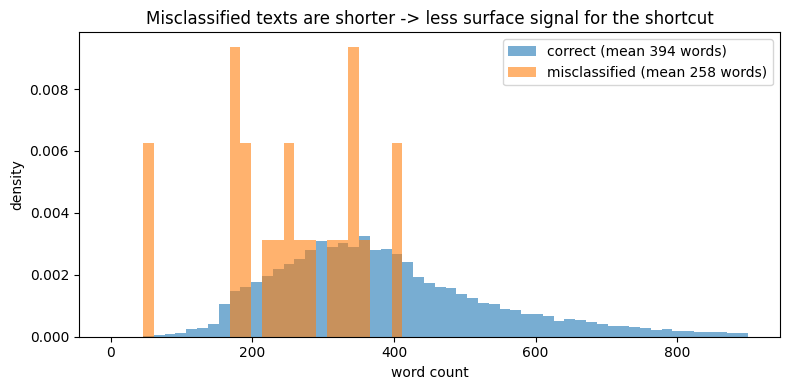

In [19]:
# Visualize the error pattern: misclassified texts are shorter.
import matplotlib.pyplot as plt
bins = np.linspace(0, 900, 60)
plt.figure(figsize=(8, 4))
plt.hist(correct.words, bins=bins, alpha=.6, density=True,
         label=f'correct (mean {correct.words.mean():.0f} words)')
plt.hist(wrong.words, bins=bins, alpha=.6, density=True,
         label=f'misclassified (mean {wrong.words.mean():.0f} words)')
plt.xlabel('word count')
plt.ylabel('density')
plt.title('Misclassified texts are shorter -> less surface signal for the shortcut')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'error_wordcount.png'), dpi=120, bbox_inches='tight')
plt.show()

## 10b. Why is the baseline ~99.9%? — reading the shortcut

A bag-of-words baseline scoring **~99.9% macro-F1**, with every model within a fraction of a
point of the others, is **not** evidence of a brilliant classifier — it's the signature of a
**trivially separable dataset**. The classes come from different sources, so a linear model
finds a surface shortcut instead of learning "AI-ness." Three artifacts drive it:

1. **Placeholder / redaction tokens** — top features like `sincerely name`, `student name`,
   `know people`. The `name` token is a redacted-name placeholder that appears differently in
   the AI vs human sources — a formatting tell, not writing style.
2. **Topic / prompt words** — `venus`, `car`, `driving`, `school`, `percent`, `paragraph`.
   The human texts are the **PERSUADE student-essay corpus** (fixed prompts about Venus,
   driverless cars, etc.). The model partly detects *which prompt set* a text came from.
3. **Essay-structure discourse markers** — `additionally`, `firstly`, `however`, `conclusion`,
   `essential`, `significant` — the polished LLM register the EDA already flagged.

**The error analysis confirms it:** the ~38 misclassified texts are OCR-**garbled**
("8tX grader", "Xix school", "GY the time") and shorter on average (~296 vs ~394 words). When
character corruption destroys the surface tokens, the shortcut breaks and the model fails —
proof it leans on lexical surface cues, not deep signal.

**Consequences to note in the report:**
- The score is **inflated by dataset artifacts**; it will *not* transfer to text from other
  prompts / other generators (poor out-of-distribution generalization).
- The DistilBERT model will likely **also** hit ~99% here, so "did the Transformer win?" will be
  within noise — the honest comparison is on *robustness*, not raw accuracy.
- **Ethics:** the false-positive direction (humans flagged as AI) mostly hits *messy/garbled*
  or non-standard writing — echoing the EDA warning about penalizing non-native / careful writers.

In [20]:
# Quantify the shortcut: how many top features are placeholders / prompt-topic words?
artifact_markers = {'name', 'student', 'venus', 'car', 'driving', 'driverless',
                    'school', 'percent', 'paragraph', 'principal', 'teacher', 'cowboy'}
coefs = best_model.coef_[0][:len(names)]
top_idx = np.r_[coefs.argsort()[-25:], coefs.argsort()[:25]]   # 25 most-AI + 25 most-human
flagged = [t for t in names[top_idx] if any(a in t.split() for a in artifact_markers)]
print(f'{len(flagged)}/50 of the strongest features are topic/placeholder artifacts:')
print('  ', ', '.join(flagged))
print()
print('Interpretation: a large share of the model\'s power comes from source/topic tells,')
print('not from genuine "AI vs human" writing signal.')

9/50 of the strongest features are topic/placeholder artifacts:
   believe student, sincerely name, comfortable school, venus, opinion student, student, paragraph, student required, driving

Interpretation: a large share of the model's power comes from source/topic tells,
not from genuine "AI vs human" writing signal.


## 11b. Save the trained models (reuse without retraining)
Persist the fitted vectorizer + both models + the chosen config to Drive, so you (or Member B)
can reload and predict without the ~4-minute refit.

In [21]:
import joblib
MODELS_DIR = os.path.join(RESULTS, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(vec_final, os.path.join(MODELS_DIR, 'tfidf_vectorizer.joblib'))
for name, mdl in final_models.items():
    joblib.dump(mdl, os.path.join(MODELS_DIR, f'{name}.joblib'))
joblib.dump({'best_ngram': BEST_NGRAM, 'best_maxf': BEST_MAXF,
             'best_C_LR': BEST_C_LR, 'best_C_SVM': BEST_C_SVM,
             'use_length': USE_LENGTH, 'best_model': best_name},
            os.path.join(MODELS_DIR, 'config.joblib'))
print('[saved] models ->', MODELS_DIR)
print(os.listdir(MODELS_DIR))

# --- reload example ---
# vec = joblib.load(f'{MODELS_DIR}/tfidf_vectorizer.joblib')
# clf = joblib.load(f'{MODELS_DIR}/LinearSVC.joblib')
# clf.predict(vec.transform(['some text ...']))

[saved] models -> /content/drive/MyDrive/NLP_project/classical_results/models
['tfidf_vectorizer.joblib', 'LogReg.joblib', 'LinearSVC.joblib', 'config.joblib']


## 11. Save results → `classical_results/` (on Drive)
Download these into the repo's `classical_model/results/` for submission.

In [22]:
leaderboard = M.results_table({
    **results_val,
    **{f'TEST: {k}': v for k, v in results_test.items()},
}).round(4)
csv_path = os.path.join(RESULTS, 'metrics_summary.csv')
leaderboard.to_csv(csv_path)
display(leaderboard)
print('[saved]', csv_path)

with open(os.path.join(RESULTS, 'baseline_score.txt'), 'w') as f:
    f.write('Classical baseline (TEST)\n')
    f.write(f'best model    : {best_name}\n')
    f.write(f'tfidf         : ngram={BEST_NGRAM}, max_features={BEST_MAXF}, length_feats={USE_LENGTH}\n')
    f.write(f'C (LR / SVM)  : {BEST_C_LR} / {BEST_C_SVM}\n')
    f.write(f'accuracy      : {baseline["accuracy"]:.4f}\n')
    f.write(f'macro_f1      : {baseline["macro_f1"]:.4f}  <- number the Transformer must beat\n')
    f.write(f'AI  P/R/F1    : {baseline["precision_AI"]:.4f}/{baseline["recall_AI"]:.4f}/{baseline["f1_AI"]:.4f}\n')
    f.write('NOTE: score is inflated by dataset artifacts (placeholders + prompt-topic words);\n')
    f.write('      see the shortcut analysis. Expect poor out-of-distribution transfer.\n')
print('[saved] baseline_score.txt')

,accuracy,macro_f1,f1_AI,recall_AI,precision_AI,f1_human
TEST: LinearSVC,0.9997,0.9997,0.9996,0.9997,0.9996,0.9998
LinearSVC (balanced),0.9995,0.9995,0.9994,0.9994,0.9993,0.9996
TEST: LogReg,0.9995,0.9995,0.9993,0.9993,0.9993,0.9996
LogReg (balanced),0.9977,0.9976,0.9970,0.9961,0.9978,0.9982
LogReg (default),0.9973,0.9971,0.9964,0.9940,0.9987,0.9978
MultinomialNB,0.9765,0.9748,0.9682,0.9585,0.9780,0.9814


[saved] /content/drive/MyDrive/NLP_project/classical_results/metrics_summary.csv
[saved] baseline_score.txt


## 12. Summary (fill in after running)

- **Models compared (TEST):** LogReg vs LinearSVC — winner = ____, macro-F1 = ____ (acc ____, AI recall ____).
- **`class_weight='balanced'`:** did it lift AI recall / macro-F1? ____
- **Length features:** kept or dropped? ____
- **The catch — shortcut:** baseline is ~99.9% because the dataset is trivially separable via
  **placeholder tokens** (`name`), **prompt-topic words** (`venus`, `car`, `school`), and
  **essay-structure markers** (`additionally`, `firstly`, `conclusion`). ____/50 top features
  were artifacts.
- **Errors:** mostly OCR-garbled / shorter texts; false positives = humans flagged as AI.
- **Implication for Week 2:** DistilBERT will likely also hit ~99% here → the meaningful
  comparison is **robustness / OOD**, not raw accuracy. Baseline macro-F1 = ____ is the target.

> Models + metrics saved under Drive `classical_results/`; copy into `classical_model/results/`.